In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
df= pd.read_csv('Titanic-Dataset.csv', sep=',')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
df['Age'].isnull().sum()
#Mediana de edad
Mediana= df['Age'].median()
#, Reemplazar directamente en el DataFrame
df['Age'].fillna(Mediana, inplace=True)
Mediana

C:\Users\Asus\AppData\Local\Temp\ipykernel_332\4160010729.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(Mediana, inplace=True)


np.float64(28.0)

In [17]:
df['Cabin'].fillna('Desconocida', inplace=True)
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       2
dtype: int64

In [21]:
modaEmbarco= df["Embarked"].mode()[0]

df["Embarked"].fillna(modaEmbarco, inplace=True)
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [23]:
Supervivientes= df[df['Survived']==1]
Supervivientes.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Desconocida,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,Desconocida,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,Desconocida,C


In [ ]:
survived_counts= df['Survived'].value_counts()
survived_counts

Survived
0    549
1    342
Name: count, dtype: int64

In [ ]:
#Creamos un Dataframe de mujeres supervivientes
Mujeres_Supervivientes= df[(df['Survived']==1)&(df['Sex']=='female')]
Mujeres_Supervivientes.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Desconocida,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,Desconocida,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,Desconocida,C


In [25]:
print("Número de mujeres supervivientes:", len(Mujeres_Supervivientes))

Número de mujeres supervivientes: 233


In [28]:
Jovenes= df[(df["Age"]>=0)&(df["Age"]<=17)]
print("Número de jóvenes a bordo:", len(Jovenes))

Número de jóvenes a bordo: 113


In [29]:
Adultos= df[(df["Age"]>=18)&(df["Age"]<=50)]
print("Número de adultos a bordo:", len(Adultos))   

Número de adultos a bordo: 714


In [30]:
Adulto_Mayores= df[(df["Age"]>50)]
print("Número de adultos mayores a bordo:", len(Adulto_Mayores))

Número de adultos mayores a bordo: 64


In [32]:
Jovenes_Supervivientes= Jovenes[Jovenes["Survived"]==1]
print("Número de jóvenes supervivientes:", len(Jovenes_Supervivientes))

Número de jóvenes supervivientes: 61


In [34]:
total_Jovenes= len(Jovenes)
total_Jovenes_Supervivientes= len(Jovenes_Supervivientes)

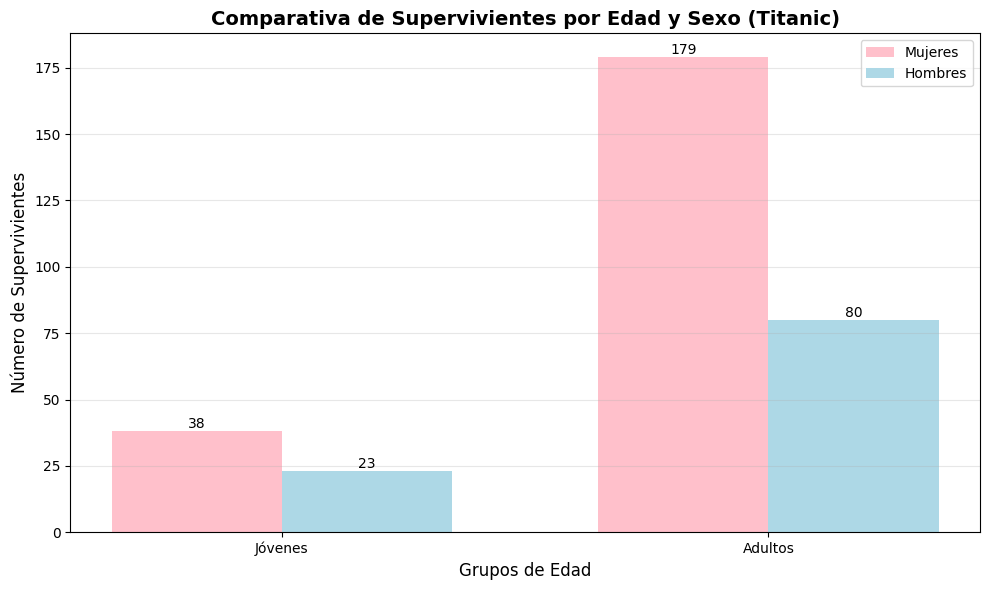

In [37]:
# Filtrar jóvenes y adultos supervivientes por sexo
jovenes_supervivientes_f = Jovenes_Supervivientes[Jovenes_Supervivientes['Sex'] == 'female']
jovenes_supervivientes_m = Jovenes_Supervivientes[Jovenes_Supervivientes['Sex'] == 'male']

adultos_supervivientes = df[(df["Age"]>=18)&(df["Age"]<=50)&(df["Survived"]==1)]
adultos_supervivientes_f = adultos_supervivientes[adultos_supervivientes['Sex'] == 'female']
adultos_supervivientes_m = adultos_supervivientes[adultos_supervivientes['Sex'] == 'male']

# Crear datos para la gráfica
categorias = ['Jóvenes', 'Adultos']
mujeres = [len(jovenes_supervivientes_f), len(adultos_supervivientes_f)]
hombres = [len(jovenes_supervivientes_m), len(adultos_supervivientes_m)]

# Crear la gráfica
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(categorias))
ancho = 0.35

barras1 = ax.bar(x - ancho/2, mujeres, ancho, label='Mujeres', color='pink')
barras2 = ax.bar(x + ancho/2, hombres, ancho, label='Hombres', color='lightblue')

# Personalizar la gráfica
ax.set_xlabel('Grupos de Edad', fontsize=12)
ax.set_ylabel('Número de Supervivientes', fontsize=12)
ax.set_title('Comparativa de Supervivientes por Edad y Sexo (Titanic)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# Agregar valores en las barras
for barras in [barras1, barras2]:
    for barra in barras:
        altura = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2., altura,
                f'{int(altura)}',
                ha='center', va='bottom')

plt.tight_layout()
plt.show()